# Assignment 3

## 1. Data Collection

In [230]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/traintest.csv")

## 2. Data Exploration

### Print information about the dataframe

In [231]:
df.info()
df.describe()
df.head()
df.value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


PassengerId  Survived  Pclass  Name                                                 Sex     Age   SibSp  Parch  Ticket    Fare     Cabin        Embarked
2            1         1       Cumings, Mrs. John Bradley (Florence Briggs Thayer)  female  38.0  1      0      PC 17599  71.2833  C85          C           1
4            1         1       Futrelle, Mrs. Jacques Heath (Lily May Peel)         female  35.0  1      0      113803    53.1000  C123         S           1
7            0         1       McCarthy, Mr. Timothy J                              male    54.0  0      0      17463     51.8625  E46          S           1
11           1         3       Sandstrom, Miss. Marguerite Rut                      female  4.0   1      1      PP 9549   16.7000  G6           S           1
12           1         1       Bonnell, Miss. Elizabeth                             female  58.0  0      0      113783    26.5500  C103         S           1
                                                         

### Grouped Barplot on Survival by Sex of Passengers

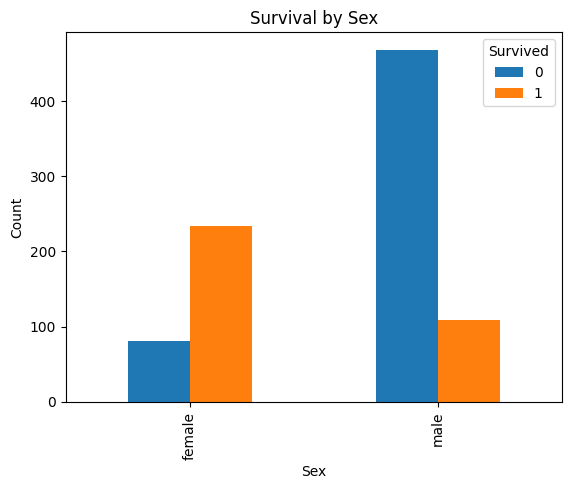

In [232]:
pd.crosstab(df['Sex'], df['Survived']).plot(
    kind='bar',
    title='Survival by Sex'
)
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show()

This grouped barplot shows that not only did women have a better percentage of survival, but also survived more overall

### Histogram on Age Distribution by Survival

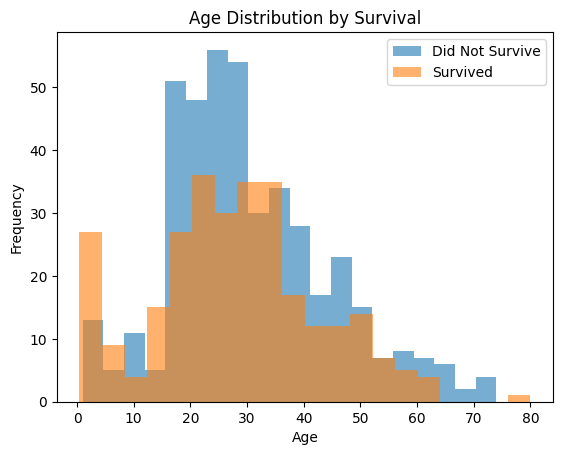

In [233]:
df[df['Survived'] == 0]['Age'].plot(
    kind='hist',
    alpha=0.6,
    bins=20,
    label='Did Not Survive',
    title='Age Distribution by Survival'
)

df[df['Survived'] == 1]['Age'].plot(
    kind='hist',
    alpha=0.6,
    bins=20,
    label='Survived'
)

plt.xlabel('Age')
plt.legend()
plt.show()

The histogram shows the age distribution by survival. Not only does it show the relation between age and survival, but also the overall age population on the ship. We see that the 20s to 30s took up a majority of the ships passengers.

### Scatterplot on Age vs Fare

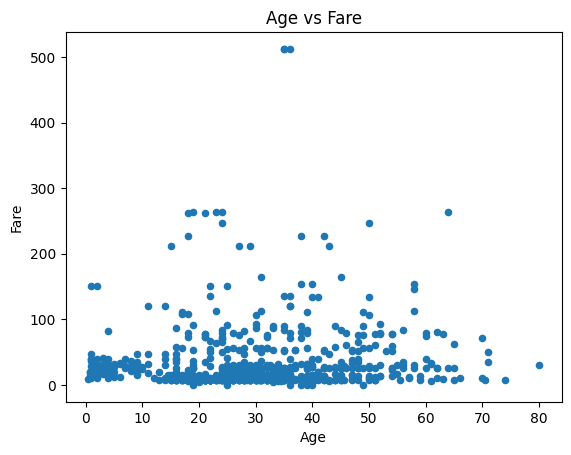

In [234]:
df.plot(
    kind='scatter',
    x='Age',
    y='Fare',
    title='Age vs Fare'
)
plt.show()


This scatterplot is meant to show the relation between age and the fare paid. Clearly, there isnt much of a relation at all, since most passengers paid the cheapest fare as shown.

## 3. Data Preparation

### Irrelevant Columns and Missing Data

In [235]:
df = df.drop(
    ['PassengerId', 'Name', 'Ticket', 'Cabin'],
    axis=1
)

df['Age'] = df['Age'].fillna(df['Age'].median())

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])


Passenger ID is just an identifier, won't help make any predictions.   

Name is unique and would not help make any kind of prediction.   

Ticket is again a unique value that has no influence on other values, so it can be dropped.   

Cabin has far too many missing values to just use a dropna as we would be losing a lot of important data. We're better off deleting it all.   

Since Age and Embarked values can be applied to our predictions, we will fill any missing values in those columns with a mean value.

### Skewed Data

Sex heavily influences survival. Female passengers had a much higher survival rate than male passengers, so this feature will probably be very important for the model.   

Pclass also influences survival. First class passengers usually had a higher survival rate than second and third class passengers, likely because of location on the ship and access to lifeboats.   

Fare is skewed because most passengers paid lower fares, while a small number paid very high fares. Higher fares often connect to higher passenger class, which may also connect to higher survival.   

Age may influence survival because children may have had a better chance of surviving. However, age has missing values, so it needs to be handled before modeling.   


### Encode String Data

In [236]:
from sklearn.preprocessing import LabelEncoder

df["Sex"] = LabelEncoder().fit_transform(df["Sex"])
df["Embarked"] = LabelEncoder().fit_transform(df["Embarked"])

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


## 4. Modeling / 5. Evaluation

### KNN

In [237]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

x = df.drop("Survived", axis=1)
y = df["Survived"]

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    random_state=1111
)

model_knn = KNeighborsClassifier(n_neighbors=9)
model_knn.fit(x_train, y_train)

y_pred_knn = model_knn.predict(x_test)

accuracy_knn = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", accuracy_knn)

print("KNN Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

KNN Accuracy: 0.7174887892376681
KNN Confusion Matrix:
[[111  19]
 [ 44  49]]


I chose KNN with n_neighbors=9 because KNN predicts based on the closest passengers. Testing a slightly higher number of neighbors improved the model's accuracy above 70%. A higher k can make the model less sensitive to individual unusual passengers.


The confusion matrix means the model correctly predicted 111 passengers who did not survive and 49 passengers who survived. It made 19 false positive mistakes, where it predicted survival but the passenger did not survive. It also made 44 false negative mistakes, where it predicted the passenger did not survive but they actually survived. KNN met the requirement, but it missed a lot of actual survivors compared with the other models.

### RandomForest

In [238]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=1111
)

model_rf.fit(x_train, y_train)

y_pred_rf = model_rf.predict(x_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", accuracy_rf)

print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.8385650224215246
Random Forest Confusion Matrix:
[[118  12]
 [ 24  69]]


I chose Random Forest because it combines many decision trees. Each tree makes a prediction, and the forest uses majority vote. This usually performs better than a single decision tree because it reduces overfitting.


The confusion matrix means the model correctly predicted 118 passengers who did not survive and 69 passengers who survived. It made 12 false positive mistakes and 24 false negative mistakes. Compared with KNN, Random Forest made fewer total mistakes and was much better at identifying actual survivors. This makes sense because Random Forest combines many decision trees and uses majority vote, which usually reduces overfitting and improves accuracy.

### Decision Tree

In [239]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(max_depth=4, random_state=1111)
model_dt.fit(x_train, y_train)

y_pred_dt = model_dt.predict(x_test)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", accuracy_dt)

print("Decision Tree Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree Accuracy: 0.820627802690583
Decision Tree Confusion Matrix:
[[115  15]
 [ 25  68]]


I chose a Decision Tree as my third classification algorithm because we used it in Lab 11, it's just a more basic level of a Random Forest and there weren't many other algorithms I could think of... A Decision Tree predicts by making a series of yes/no splits based on passenger features such as `Sex`, `Pclass`, `Age`, and `Fare`. I used `max_depth=4` to prevent the tree from becoming too complex and overfitting the training data.

The confusion matrix means the model correctly predicted 115 passengers who did not survive and 68 passengers who survived. It made 15 false positive mistakes and 25 false negative mistakes. The Decision Tree performed close to Random Forest, but Random Forest was slightly better overall because it made fewer mistakes. This shows why ensemble methods can improve on a single tree.

## 6. Predict on Unseen Data

In [240]:
predict_df = pd.read_csv("../data/predict.csv")
tested_df = pd.read_csv("../data/tested.csv")

predict_df = predict_df.drop(
    ['PassengerId', 'Name', 'Ticket', 'Cabin'],
    axis=1
)

predict_df['Age'] = predict_df['Age'].fillna(predict_df['Age'].median())
predict_df['Fare'] = predict_df['Fare'].fillna(predict_df['Fare'].median())
predict_df['Embarked'] = predict_df['Embarked'].fillna('S')

predict_df["Sex"] = LabelEncoder().fit_transform(predict_df["Sex"])
predict_df["Embarked"] = LabelEncoder().fit_transform(predict_df["Embarked"])

actual_survival = tested_df['Survived']

In [241]:
knn_predict = model_knn.predict(predict_df)
rf_predict = model_rf.predict(predict_df)
dt_predict = model_dt.predict(predict_df)

print("KNN Prediction Accuracy:", accuracy_score(actual_survival, knn_predict))
print("KNN Prediction Confusion Matrix:")
print(confusion_matrix(actual_survival, knn_predict))

print("Random Forest Prediction Accuracy:", accuracy_score(actual_survival, rf_predict))
print("Random Forest Prediction Confusion Matrix:")
print(confusion_matrix(actual_survival, rf_predict))

print("Decision Tree Prediction Accuracy:", accuracy_score(actual_survival, dt_predict))
print("Decision Tree Prediction Confusion Matrix:")
print(confusion_matrix(actual_survival, dt_predict))

KNN Prediction Accuracy: 0.6626794258373205
KNN Prediction Confusion Matrix:
[[212  54]
 [ 87  65]]
Random Forest Prediction Accuracy: 0.8229665071770335
Random Forest Prediction Confusion Matrix:
[[228  38]
 [ 36 116]]
Decision Tree Prediction Accuracy: 0.9497607655502392
Decision Tree Prediction Confusion Matrix:
[[253  13]
 [  8 144]]


I used the three trained models to predict survival for the passengers in `../data/predict.csv`. Since this file does not include the `Survived` column, I compared the predictions against `../data/tested.csv`, which contains the real answers.

The same cleaning steps were used on the prediction data: I removed the irrelevant columns, filled missing values, and encoded the string columns. This is important because the prediction data must have the same columns and format as the training data.

The Decision Tree had the best accuracy on the unseen prediction data. Random Forest also performed well, while KNN was weaker on the unseen data. This shows that a model can meet the accuracy requirement on the test split but still perform differently when used on new passenger data.

## 7. Conclusion

Overall, the best model was the Decision Tree on the unseen prediction data, while Random Forest was the best on my original train/test split. KNN passed the 70% requirement, but it was the weakest of the three models.

The most important features for predicting survival were `Sex`, `Pclass`, `Fare`, and `Age`. The exploration showed that female passengers had a much higher survival rate than male passengers. Passenger class and fare also mattered because first class and higher fare passengers generally had better survival chances.

From this analysis, I learned that Titanic survival was not random. Survival was strongly connected to passenger characteristics like sex, class, and age. I also learned that different classification algorithms can give different results even when they use the same cleaned dataset.